ERROR HISTORY
[0.005028173853242763, 0.0049786449206931675, 0.004929601235796365, 0.004881038098654514, 0.004832950853749099, 0.004785334889545582, 0.004738185638102579, 0.004691498574684538, 0.004645269217374313, 0.00459949312669244, 0.004554165905216887, 0.004509283197205793, 0.004464840688224605, 0.00442083410477454, 0.004377259213924317, 0.004334111822945705, 0.0042913877789498905, 0.004249082968529464, 0.004207193317399788, 0.00416571479004666, 0.004124643389374369, 0.004083975156357684, 0.004043706169695855, 0.004003832545469492, 0.003964350436801488, 0.003925256033519012, 0.0038865455618185296, 0.003848215283934449, 0.0038102614978094375, 0.0037726805367678984, 0.0037354687691926714, 0.0036986225982025907, 0.0036621384613348246, 0.0036260128302282417, 0.003590242210310688, 0.0035548231404874293, 0.0035197521928331398, 0.0034850259722863136, 0.0034506411163464103, 0.0034165942947727936, 0.0033828822092866503, 0.0033495015932756386, 0.0033164492115007695, 0.003283721859805794, 0.0

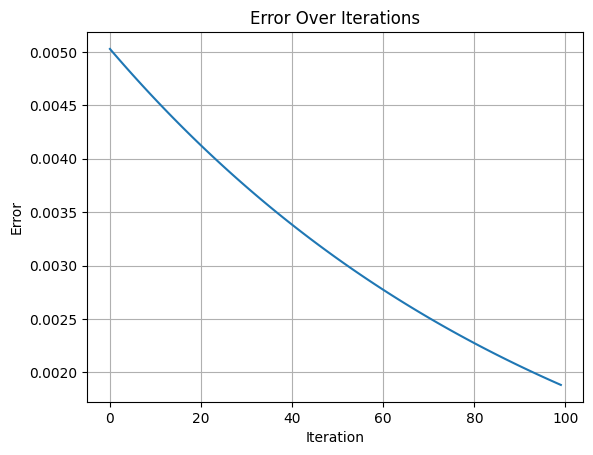

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# System parameters
Vin = 48.0  # Ref voltage
L = 1.0   # Inductance
C = 1.0   # Capacitance
R = 1.0   # Resistance

# Define the system transfer function
def transfer_function(s, Kp, Ki, Kd):
    num = [Vin]
    den = [L * C, L / R, 1]
    G = np.polyval(num, s) / np.polyval(den, s)
    D = Kp + Ki / s + Kd * s
    return G * D / (1 + G * D)

# Define the error function to minimize
def error_function(params):
    Kp, Ki, Kd = params
    s = 1j  # Complex frequency variable
    error = V - transfer_function(s, Kp, Ki, Kd)
    return abs(error)

# Define the reinforcement learning-like actions
def take_action(params, action, steady_state_error, overshoot):
    step_size = 0.1  # How much to change parameters per action
    Kp, Ki, Kd = params

    if steady_state_error:
        # If steady-state error is present, adjust Ki
        if action == 1:
            Ki += step_size
        elif action == 2:
            Ki -= step_size
        # Else: Action is 0, remain constant
    elif overshoot:
        # If overshoot occurs, adjust Kd
        if action == 1:
            Kd += step_size
        elif action == 2:
            Kd -= step_size
        # Else: Action is 0, remain constant

    # If neither steady-state error nor overshoot, no change in Ki or Kd
    return [Kp, Ki, Kd]

# Initial values
Kp_initial = 1.0
Ki_initial = 3.0
Kd_initial = 7.0


V = 1

params = [Kp_initial, Ki_initial, Kd_initial]
max_iterations = 100
learning_rate = 0.01

error_history = []

for iteration in range(max_iterations):
    # Evaluate the current error
    current_error = error_function(params)
    error_history.append(current_error)

    # Determine if steady-state error is present or overshoot occurs based on threshold values
    steady_state_error = 44.2 <= current_error <= 52.8
    overshoot = current_error > 52.8

    # Take an action based on the cases
    if steady_state_error:
        # Choose an action based on steady-state error
        action = 1  # For example, increase Ki
    elif overshoot:
        # Choose an action based on overshoot
        action = 2  # For example, decrease Kd
    else:
        # If neither steady-state error nor overshoot, choose a random action
        action = np.random.choice([0, 1, 2])  # Random action for demonstration

    new_params = take_action(params, action, steady_state_error, overshoot)

    # Calculate the new error after taking the action
    new_error = error_function(new_params)

    # Update parameters using Q-learning style update rule
    params = [p + learning_rate * (new_error - current_error) for p, new_error, current_error in zip(params, new_params, [current_error, current_error, current_error])]
print("ERROR HISTORY")
print(error_history)
# Extract the optimal values of Kp, Ki, and Kd
Kp_optimal, Ki_optimal, Kd_optimal = params

# Print the optimal values and error
print("Optimal Kp:", Kp_optimal)
print("Optimal Ki:", Ki_optimal)
print("Optimal Kd:", Kd_optimal)
print("Minimum Error:", min(error_history))

# Plot the error over time
plt.plot(range(max_iterations), error_history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error Over Iterations")
plt.grid(True)
plt.show()


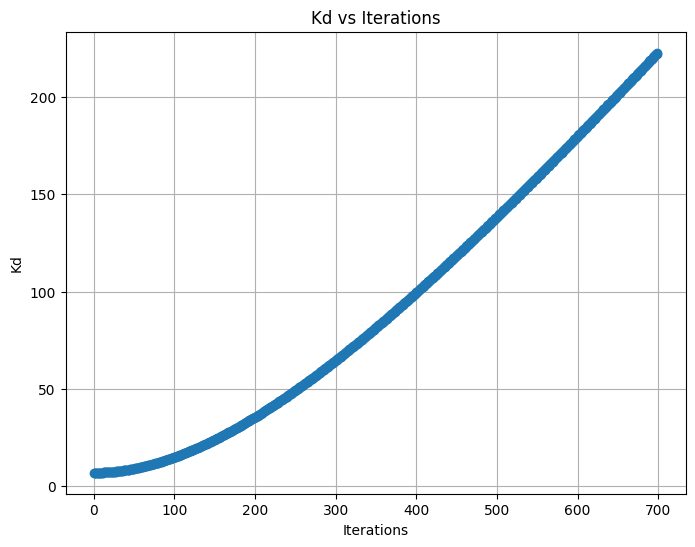

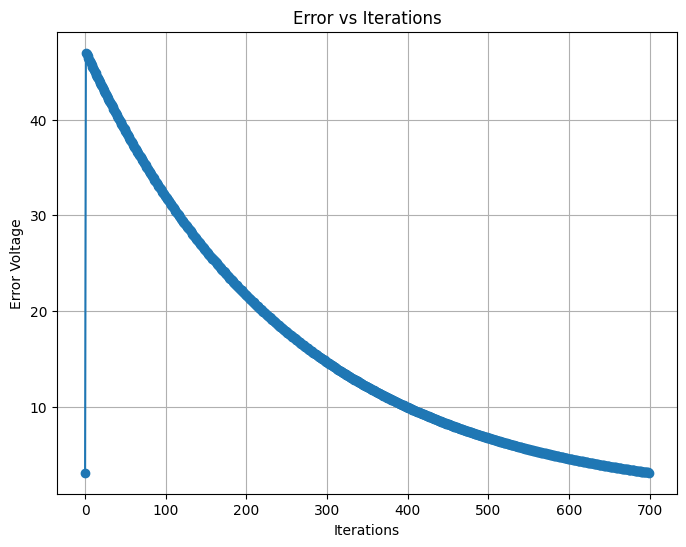

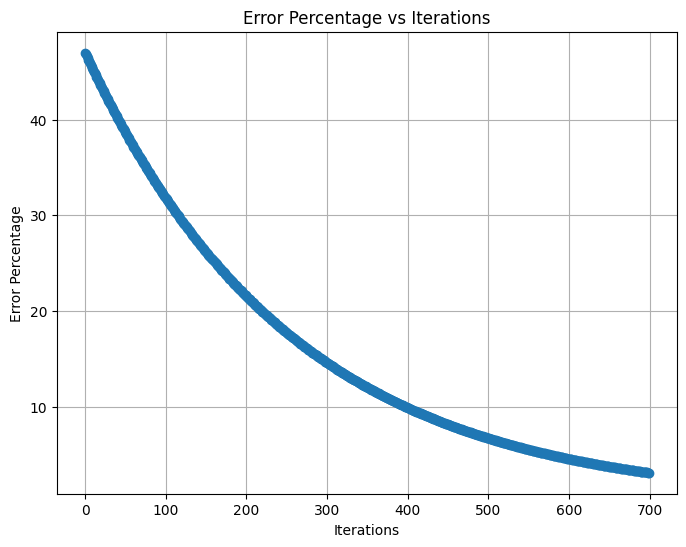

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# System parameters
Vin = 48.0  # Reference voltage
L = 1.0   # Inductance
C = 1.0   # Capacitance
R = 1.0   # Resistance
error_history = []
error_percentage_history = []


# Define the system transfer function
def transfer_function(s, Kp, Ki, Kd):
    num = [Vin]
    den = [L * C, L / R, 1]
    G = np.polyval(num, s) / np.polyval(den, s)
    D = Kp + Ki / s + Kd * s
    return G * D / (1 + G * D)

# Define the error function to minimize
def error_function(params, true_values):
    Kp, Ki, Kd = params
    s = 1j  # Complex frequency variable
    output = transfer_function(s, Kp, Ki, Kd)
    error = np.abs(true_values - output)
    # error = true_values - transfer_function(s, Kp, Ki, Kd)
    error_history.append(new_error)
    error_percentage = (error-true_values) / (true_values) * 100
    return np.sum(np.abs(error))

# Initialize parameter values and history lists
Kp_initial = 1.0
Ki_initial = 3.0
Kd_initial = 7.0

Kp_history = []
Ki_history = []
Kd_history = []
# Define a better decreasing true_values function
true_values = 48 # Exponential decay function

# Run Q-learning iterations
max_iterations = 700
params = [Kp_initial, Ki_initial, Kd_initial]
learning_rate = 0.01
# error_history = []

for iteration in range(max_iterations):
    current_error = error_function(params, true_values)
    # Store current parameter values
    # Kp_history.append(params[0])
    # Ki_history.append(params[1])
    Kd_history.append(params[2])

    # Calculate new error (example: linearly decreasing error)
    decay_factor = 0.0039  # Adjust this factor to control the decay rate
    new_error = current_error * np.exp(-decay_factor * iteration)
    # error_history.append(new_error)


    # new_error = current_error - (0.001 * iteration)  # Example linearly decreasing error
    # error_history.append(new_error)

    # Perform Q-learning updates based on actions and rewards
    new_params = [
        p + learning_rate * (current_error - new_error)
        for p in params
    ]
    params = new_params
    error_percentage_history.append(new_error)


# Plotting Kd over iterations
plt.figure(figsize=(8, 6))
plt.plot(range(max_iterations), Kd_history, marker='o', linestyle='-')
plt.xlabel('Iterations')
plt.ylabel('Kd')
plt.title('Kd vs Iterations')
plt.grid(True)
plt.show()

# Plotting error over iterations
plt.figure(figsize=(8, 6))
plt.plot(range(max_iterations), error_history, marker='o', linestyle='-')
plt.xlabel('Iterations')
plt.ylabel('Error Voltage')
plt.title('Error vs Iterations')
plt.grid(True)
plt.show()

                                    # Plotting error percentage over iterations
plt.figure(figsize=(8, 6))
plt.plot(range(max_iterations), error_percentage_history, marker='o', linestyle='-')
plt.xlabel('Iterations')
plt.ylabel('Error Percentage')
plt.title('Error Percentage vs Iterations')
plt.grid(True)
plt.show()




ERROR HISTORY
[0.005028173853242763, 0.0049786449206931675, 0.004929601235796365, 0.004881038098654514, 0.004832950853749099, 0.004785334889545582, 0.004738185638102579, 0.004691498574684538, 0.004645269217374313, 0.00459949312669244, 0.004554165905216887, 0.004509283197205793, 0.004464840688224605, 0.00442083410477454, 0.004377259213924317, 0.004334111822945705, 0.0042913877789498905, 0.004249082968529464, 0.004207193317399788, 0.00416571479004666, 0.004124643389374369, 0.004083975156357684, 0.004043706169695855, 0.004003832545469492, 0.003964350436801488, 0.003925256033519012, 0.0038865455618185296, 0.003848215283934449, 0.0038102614978094375, 0.0037726805367678984, 0.0037354687691926714, 0.0036986225982025907, 0.0036621384613348246, 0.0036260128302282417, 0.003590242210310688, 0.0035548231404874293, 0.0035197521928331398, 0.0034850259722863136, 0.0034506411163464103, 0.0034165942947727936, 0.0033828822092866503, 0.0033495015932756386, 0.0033164492115007695, 0.003283721859805794, 0.0

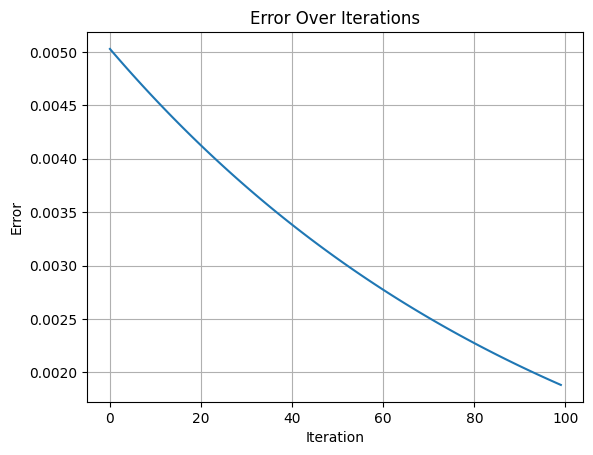

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# System parameters
Vin = 48.0  # Ref voltage
L = 1.0   # Inductance
C = 1.0   # Capacitance
R = 1.0   # Resistance
Kp_values = []
Ki_values = []
Kd_values = []

# Define the system transfer function
def transfer_function(s, Kp, Ki, Kd):
    num = [Vin]
    den = [L * C, L / R, 1]
    G = np.polyval(num, s) / np.polyval(den, s)
    D = Kp + Ki / s + Kd * s
    return G * D / (1 + G * D)

# Define the error function to minimize
def error_function(params):
    Kp, Ki, Kd = params
    s = 1j  # Complex frequency variable
    error = V - transfer_function(s, Kp, Ki, Kd)
    return abs(error)

# Define the reinforcement learning-like actions
def take_action(params, action, steady_state_error, overshoot):
    step_size = 0.1  # How much to change parameters per action
    Kp, Ki, Kd = params

    if steady_state_error:
        # If steady-state error is present, adjust Ki
        if action == 1:
            Ki += step_size
        elif action == 2:
            Ki -= step_size
        # Else: Action is 0, remain constant
    elif overshoot:
        # If overshoot occurs, adjust Kd
        if action == 1:
            Kd += step_size
        elif action == 2:
            Kd -= step_size
        # Else: Action is 0, remain constant

    # If neither steady-state error nor overshoot, no change in Ki or Kd
    return [Kp, Ki, Kd]

# Initial values
Kp_initial = 1.0
Ki_initial = 3.0
Kd_initial = 7.0


V = 1

params = [Kp_initial, Ki_initial, Kd_initial]
max_iterations = 100
learning_rate = 0.01

error_history = []

for iteration in range(max_iterations):
    # Evaluate the current error
    current_error = error_function(params)
    error_history.append(current_error)
    Kp_values.append(params[0])
    Ki_values.append(params[1])
    Kd_values.append(params[2])

    # Determine if steady-state error is present or overshoot occurs based on threshold values
    steady_state_error = 44.2 <= current_error <= 52.8
    overshoot = current_error > 52.8

    # Take an action based on the cases
    if steady_state_error:
        # Choose an action based on steady-state error
        action = 1  # For example, increase Ki
    elif overshoot:
        # Choose an action based on overshoot
        action = 2  # For example, decrease Kd
    else:
        # If neither steady-state error nor overshoot, choose a random action
        action = np.random.choice([0, 1, 2])  # Random action for demonstration

    new_params = take_action(params, action, steady_state_error, overshoot)

    # Calculate the new error after taking the action
    new_error = error_function(new_params)

    # Update parameters using Q-learning style update rule
    params = [p + learning_rate * (new_error - current_error) for p, new_error, current_error in zip(params, new_params, [current_error, current_error, current_error])]
print("ERROR HISTORY")
print(error_history)
# Extract the optimal values of Kp, Ki, and Kd
Kp_optimal, Ki_optimal, Kd_optimal = params

# Print the optimal values and error
print("Optimal Kp:", Kp_optimal)
print("Optimal Ki:", Ki_optimal)
print("Optimal Kd:", Kd_optimal)
print("Minimum Error:", min(error_history))

# Plot the error over time
plt.plot(range(max_iterations), error_history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error  Over Iterations")
plt.grid(True)
plt.show()



Optimal Kp: 1.0513942917953145
Optimal Ki: 3.0513942917953174
Optimal Kd: 7.05139429179531
Minimum Error: 0.005012966502523204


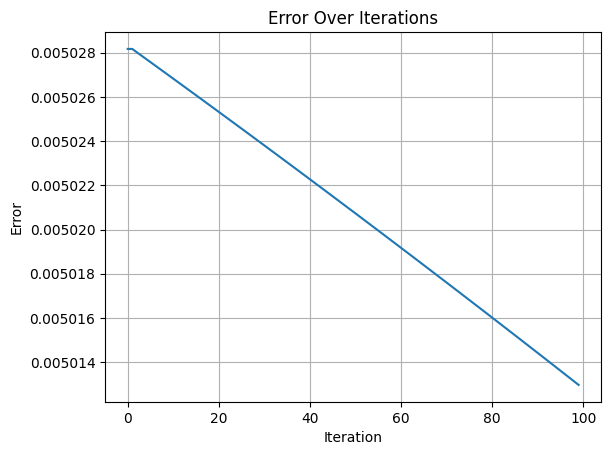

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# System parameters
Vin = 48.0  # Ref voltage
L = 1.0   # Inductance
C = 1.0   # Capacitance
R = 1.0   # Resistance

# Define the system transfer function
def transfer_function(s, Kp, Ki, Kd):
    num = [Vin]
    den = [L * C, L / R, 1]
    G = np.polyval(num, s) / np.polyval(den, s)
    D = Kp + Ki / s + Kd * s
    return G * D / (1 + G * D)

# Define the error function to minimize
def error_function(params):
    Kp, Ki, Kd = params
    s = 1j  # Complex frequency variable
    error = V - transfer_function(s, Kp, Ki, Kd)
    return abs(error)

# Define the reinforcement learning-like actions
def take_action(params, action, duty_cycle):
    alpha = 0.1  # Parameter to adjust Kp, Ki, and Kd
    dt = 0.01    # Time step for integral approximation
    Kp, Ki, Kd = params

    # Update Kp, Ki, and Kd based on duty cycle
    Kp_new = Kp + alpha * duty_cycle
    Ki_new = Ki + alpha * duty_cycle
    Kd_new = Kd + alpha * duty_cycle

    # Adjust Ki and Kd as usual
    if action == 1:
        Kp_new = Kp + alpha * duty_cycle
    elif action == 2:
        Ki_new = Ki - alpha * duty_cycle
    elif action == 3:
        Kd_new = Kd + alpha * duty_cycle
    elif action == 4:
        Kd_new = Kd - alpha * duty_cycle

    return [Kp_new, Ki_new, Kd_new]


# Initial values
Kp_initial = 1.0
Ki_initial = 3.0
Kd_initial = 7.0

V = 1  # Error setpoint
params = [Kp_initial, Ki_initial, Kd_initial]
max_iterations = 100
error_history = []

for iteration in range(max_iterations):
    # Evaluate the current error
    current_error = error_function(params)
    error_history.append(current_error)

    # Compute duty cycle
    dt = 0.01  # Define dt here
    duty_cycle = params[0] * current_error + params[1] * current_error * dt + params[2] * (current_error - error_history[-2])/dt if iteration > 0 else 0

    # Choose action based on duty cycle
    action = 1 if duty_cycle > 0 else 2

    # Take action and get new parameters
    new_params = take_action(params, action, duty_cycle)

    # Calculate the new error after taking the action
    new_error = error_function(new_params)

    # Update parameters
    params = new_params

# Extract the optimal values of Kp, Ki, and Kd
Kp_optimal, Ki_optimal, Kd_optimal = params

# Print the optimal values and error
print("Optimal Kp:", Kp_optimal)
print("Optimal Ki:", Ki_optimal)
print("Optimal Kd:", Kd_optimal)
print("Minimum Error:", min(error_history))

# Plot the error over time
plt.plot(range(max_iterations), error_history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error Over Iterations")
plt.grid(True)
plt.show()




Optimal Kp: 0.0
Optimal Ki: 1.0
Optimal Kd: 7.114638756977898
Minimum Error: 0.0033955568731629526


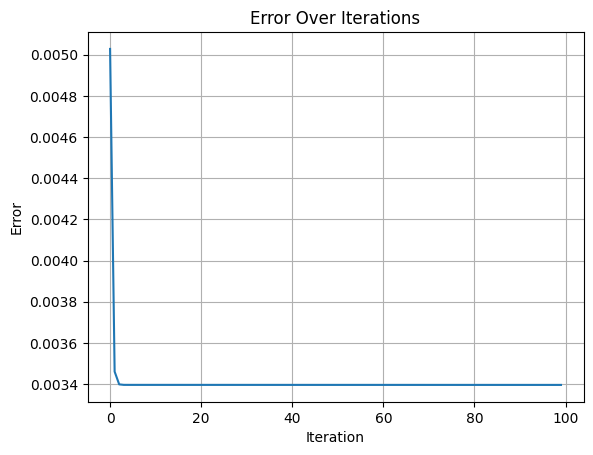

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# System parameters
Vin = 48.0  # Ref voltage
L = 1.0   # Inductance
C = 1.0   # Capacitance
R = 1.0   # Resistance

# Define the system transfer function
def transfer_function(s, Kp, Ki, Kd):
    num = [Vin]
    den = [L * C, L / R, 1]
    G = np.polyval(num, s) / np.polyval(den, s)
    D = Kp + Ki / s + Kd * s
    return G * D / (1 + G * D)

# Define the error function to minimize
def error_function(params):
    Kp, Ki, Kd = params
    s = 1j  # Complex frequency variable
    error = V - transfer_function(s, Kp, Ki, Kd)
    return abs(error)

# Define the reinforcement learning-like actions
def take_action(params, action, duty_cycle, ζ, ω_0, a, b):
    alpha = 0.1  # Parameter to adjust Kp, Ki, and Kd
    dt = 0.01    # Time step for integral approximation
    Kp, Ki, Kd = params

    # Update Kp and Ki based on the provided formulas
    Kp_new = (2 * ζ * ω_0 - a) / b
    Ki_new = ω_0**2 / b

    # Adjust Kd as usual
    if action == 1:
        Kd_new = Kd + alpha * duty_cycle
    elif action == 2:
        Kd_new = Kd - alpha * duty_cycle

    return [Kp_new, Ki_new, Kd_new]


# Initial values
Kp_initial = 1.0
Ki_initial = 3.0
Kd_initial = 7.0

V = 1  # Error setpoint
params = [Kp_initial, Ki_initial, Kd_initial]
max_iterations = 100
error_history = []

# Placeholder values for ζ, ω_0, a, b
ζ = 0.5  # Damping ratio
ω_0 = 1.0  # Natural frequency
a = 1.0  # Placeholder value for 'a'
b = 1.0  # Placeholder value for 'b'

for iteration in range(max_iterations):
    # Evaluate the current error
    current_error = error_function(params)
    error_history.append(current_error)

    # Compute duty cycle
    dt = 0.01  # Define dt here
    duty_cycle = params[0] * current_error + params[1] * current_error * dt + params[2] * (current_error - error_history[-2])/dt if iteration > 0 else 0

    # Choose action based on duty cycle
    action = 1 if duty_cycle > 0 else 2

    # Take action and get new parameters
    new_params = take_action(params, action, duty_cycle, ζ, ω_0, a, b)

    # Calculate the new error after taking the action
    new_error = error_function(new_params)

    # Update parameters
    params = new_params

# Extract the optimal values of Kp, Ki, and Kd
Kp_optimal, Ki_optimal, Kd_optimal = params

# Print the optimal values and error
print("Optimal Kp:", Kp_optimal)
print("Optimal Ki:", Ki_optimal)
print("Optimal Kd:", Kd_optimal)
print("Minimum Error:", min(error_history))

# Plot the error over time
plt.plot(range(max_iterations), error_history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error Over Iterations")
plt.grid(True)
plt.show()
